# 두산 로보틱스 머신러닝/딥러닝 입문 실습

## 환경 설정

In [3]:
# 필요한 라이브러리 설치 및 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# PyTorch 관련 임포트
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

# 시각화 설정
plt.style.use('default')
sns.set_palette("husl")

# PyTorch 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


## Part 1: 전통적인 머신러닝 (Iris 데이터셋)

Iris 데이터셋은 붓꽃의 꽃받침과 꽃잎 크기로 세 가지 종을 분류하는 고전적인 데이터셋입니다.

해당 예시를 통해 꽃을 분류하는 머신러닝 모델을 제작합니다.

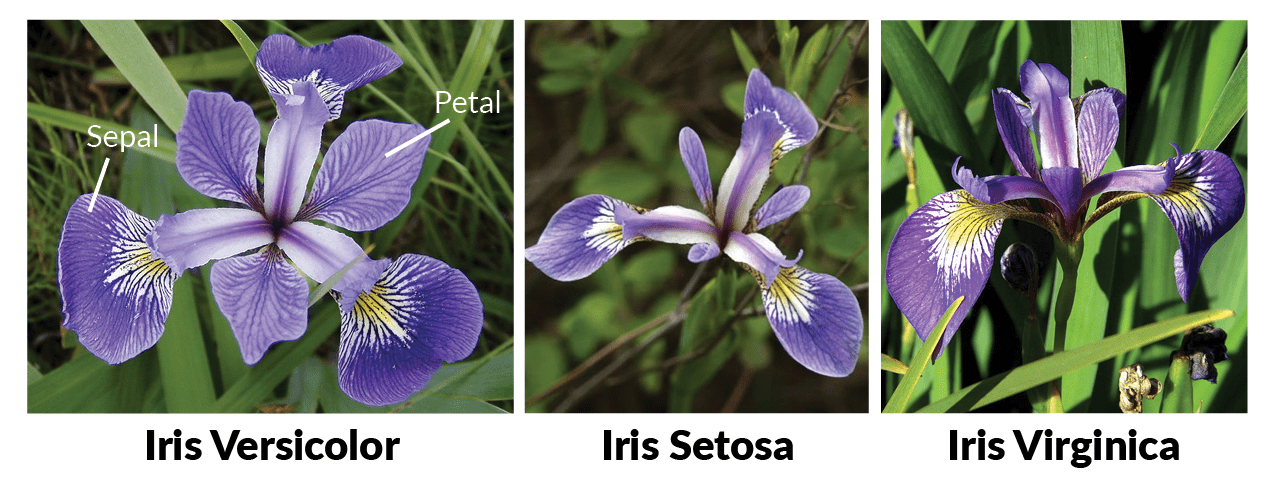

Iris 데이터셋 정보
샘플 수: 150
특성 수: 4
클래스 수: 3

클래스 종류: ['setosa' 'versicolor' 'virginica']

첫 5개 샘플:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

기본 통계:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000 

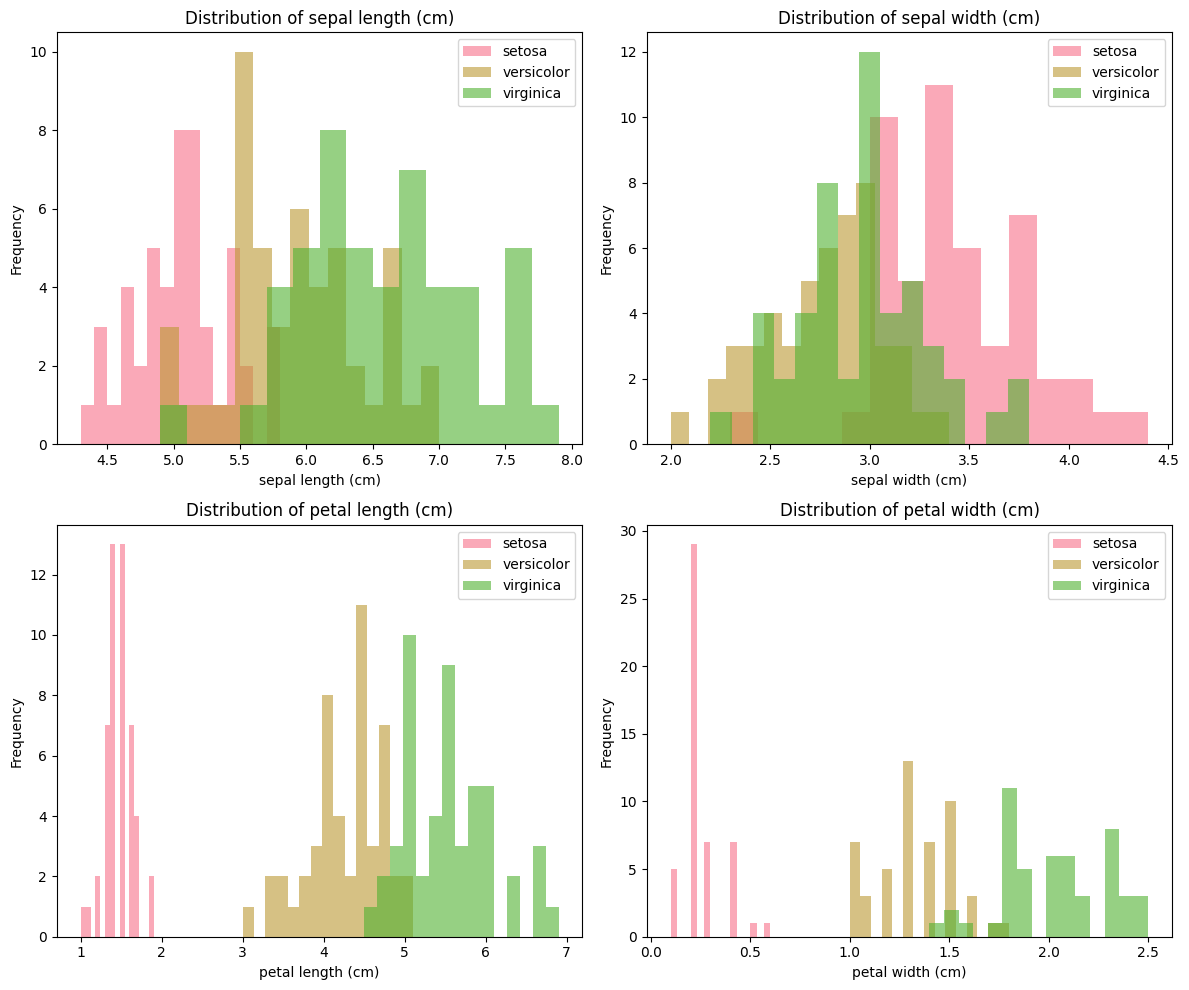

<Figure size 1200x1000 with 0 Axes>

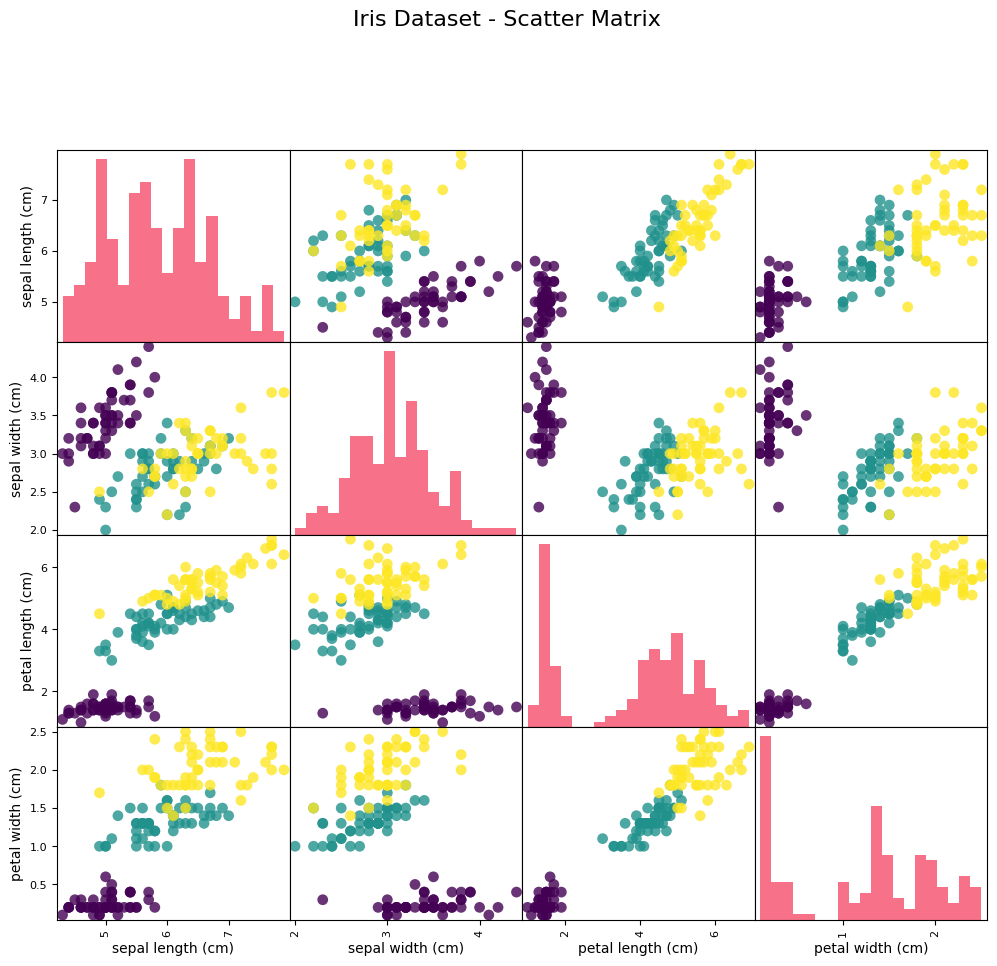


데이터 분할 정보
학습 데이터: 105 샘플
테스트 데이터: 45 샘플

모델 성능 비교

Logistic Regression
Accuracy: 0.9111

Decision Tree
Accuracy: 0.9111

Random Forest
Accuracy: 0.8889


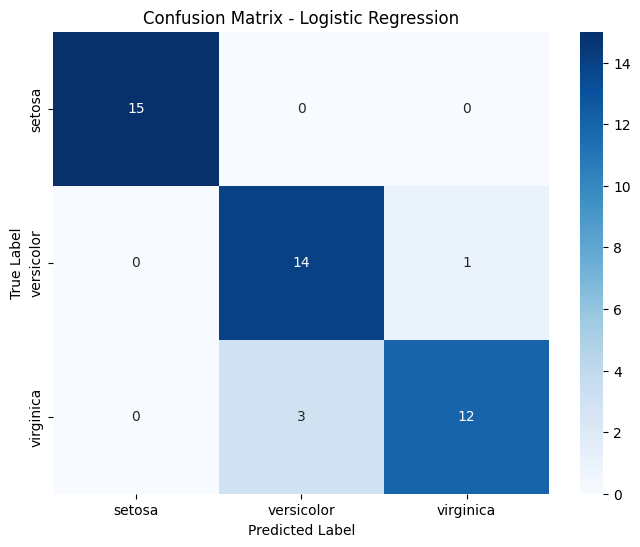


Logistic Regression - Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



In [4]:
# 1.1 데이터 로드 및 탐색
iris = load_iris()
X = iris.data
y = iris.target

# 데이터프레임으로 변환하여 확인
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(y, iris.target_names)

print("=" * 60)
print("Iris 데이터셋 정보")
print("=" * 60)
print(f"샘플 수: {len(df)}")
print(f"특성 수: {len(iris.feature_names)}")
print(f"클래스 수: {len(iris.target_names)}")
print(f"\n클래스 종류: {iris.target_names}")
print("\n첫 5개 샘플:")
print(df.head())
print("\n기본 통계:")
print(df.describe())

# 1.2 데이터 시각화
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 특성별 분포
for idx, feature in enumerate(iris.feature_names):
    ax = axes[idx // 2, idx % 2]
    for species_idx, species_name in enumerate(iris.target_names):
        data = df[df['species'] == species_name][feature]
        ax.hist(data, alpha=0.6, label=species_name, bins=15)
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {feature}')
    ax.legend()

plt.tight_layout()
plt.show()

# 산점도 행렬
fig = plt.figure(figsize=(12, 10))
pd.plotting.scatter_matrix(df.iloc[:, :4], c=y, figsize=(12, 10),
                          marker='o', hist_kwds={'bins': 20}, s=60,
                          alpha=0.8, cmap='viridis')
plt.suptitle('Iris Dataset - Scatter Matrix', y=1.02, fontsize=16)
plt.show()

# 1.3 데이터 전처리
# 학습/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 특성 스케일링 (표준화)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n" + "=" * 60)
print("데이터 분할 정보")
print("=" * 60)
print(f"학습 데이터: {X_train.shape[0]} 샘플")
print(f"테스트 데이터: {X_test.shape[0]} 샘플")

# 1.4 모델 학습 및 평가
models = {
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

print("\n" + "=" * 60)
print("모델 성능 비교")
print("=" * 60)

for name, model in models.items():
    # 모델 학습
    model.fit(X_train_scaled, y_train)

    # 예측
    y_pred = model.predict(X_test_scaled)

    # 정확도 계산
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

    print(f"\n{name}")
    print(f"Accuracy: {accuracy:.4f}")

# 1.5 최고 성능 모델의 혼동 행렬
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(f"\n{best_model_name} - Classification Report:")
print(classification_report(y_test, y_pred_best,
                          target_names=iris.target_names))

## Part 2: 딥러닝 기초 with PyTorch (MNIST 데이터셋)

MNIST는 손글씨 숫자(0-9) 이미지를 분류하는 딥러닝 입문용 데이터셋입니다.


MNIST 데이터셋 로딩 중...


100%|██████████| 9.91M/9.91M [00:00<00:00, 50.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.72MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.85MB/s]


학습 이미지: 60000
테스트 이미지: 10000
배치 크기: 128


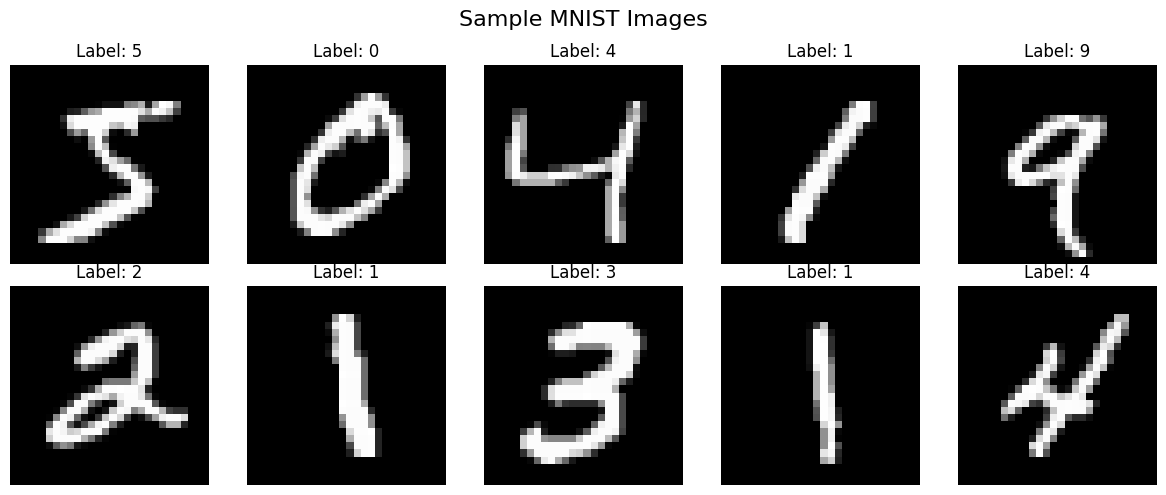


신경망 모델 구조
NeuralNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

총 파라미터 수: 109,386
학습 가능한 파라미터 수: 109,386

모델 학습 시작
Epoch [1/10], Train Loss: 0.4080, Train Acc: 87.54%, Val Loss: 0.1710, Val Acc: 94.44%
Epoch [2/10], Train Loss: 0.1877, Train Acc: 94.33%, Val Loss: 0.1173, Val Acc: 96.36%
Epoch [3/10], Train Loss: 0.1432, Train Acc: 95.61%, Val Loss: 0.0953, Val Acc: 96.98%
Epoch [4/10], Train Loss: 0.1199, Train Acc: 96.31%, Val Loss: 0.0807, Val Acc: 97.49%
Epoch [5/10], Train Loss: 0.1094, Train Acc: 96.67%, Val Loss: 0.0732, Val Acc: 97.73%
Epoch [6/10], Train Loss: 0.0934, Train Acc: 97.07%, Val Loss: 0.0763, Val Acc: 97.72%
Epoch [7/10], Train Loss: 0.0852, Train Acc: 97.3

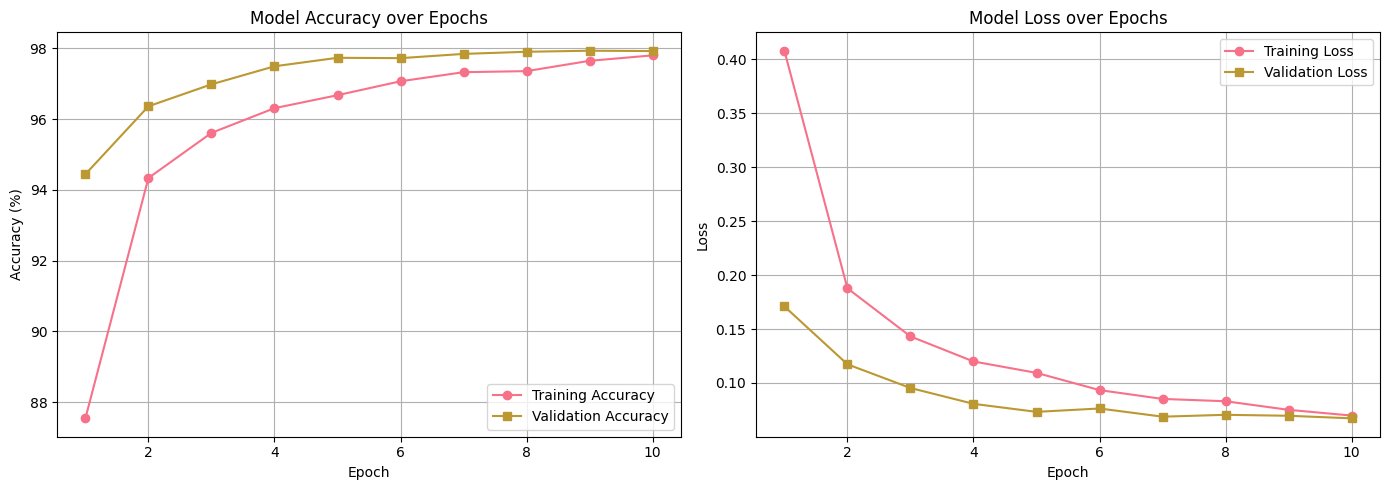


테스트 데이터 평가 결과
Test Accuracy: 97.92%


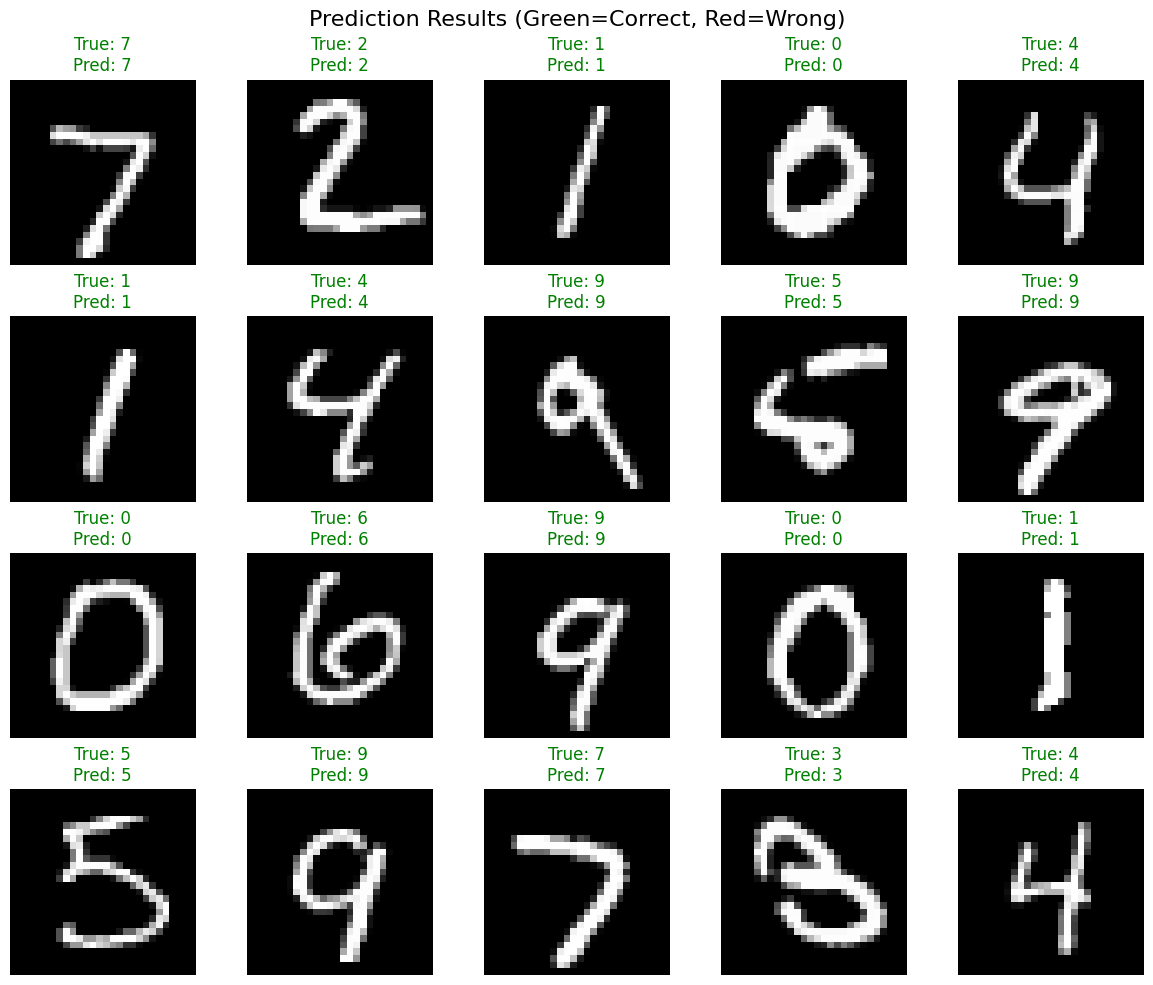

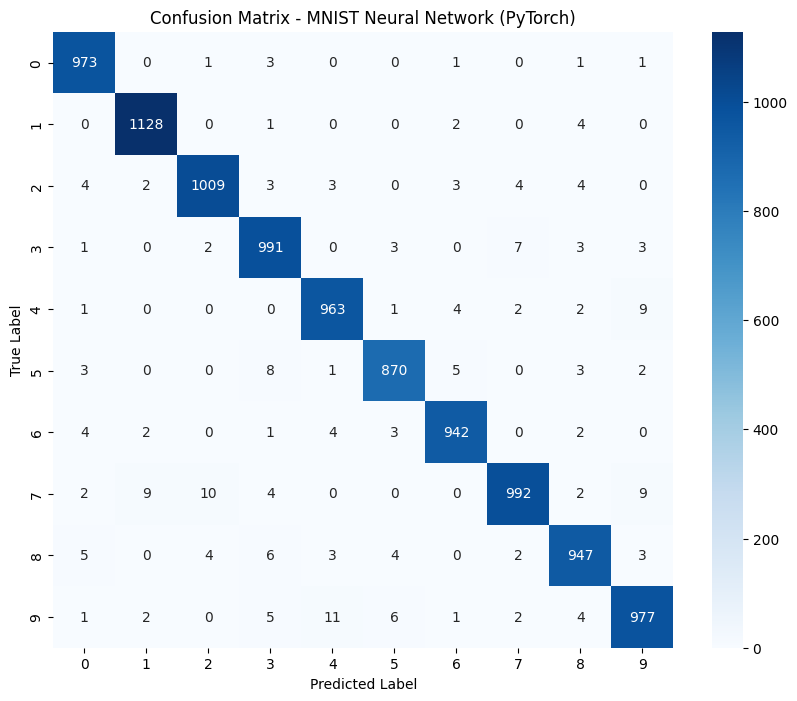

In [5]:
# 2.1 MNIST 데이터 로드 및 전처리
print("\n" + "=" * 60)
print("MNIST 데이터셋 로딩 중...")
print("=" * 60)

# 데이터 변환 정의 (정규화)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST 평균과 표준편차
])

# 학습 및 테스트 데이터셋 로드
train_dataset = datasets.MNIST(root='./data', train=True,
                               download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False,
                              download=True, transform=transform)

# 데이터로더 생성
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"학습 이미지: {len(train_dataset)}")
print(f"테스트 이미지: {len(test_dataset)}")
print(f"배치 크기: {batch_size}")

# 2.2 데이터 시각화
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    ax = axes[i // 5, i % 5]
    image, label = train_dataset[i]
    # Tensor를 numpy로 변환하고 정규화 해제
    img = image.squeeze().numpy()
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.suptitle('Sample MNIST Images', fontsize=16)
plt.tight_layout()
plt.show()

# 2.3 신경망 모델 정의
class NeuralNet(nn.Module):
    def __init__(self):
        super(NeuralNet, self).__init__()
        # 입력층: 28x28 = 784
        self.flatten = nn.Flatten()

        # 은닉층들
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.2)

        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)

        # 출력층: 10개 클래스
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

# 모델 인스턴스 생성
model = NeuralNet().to(device)

print("\n" + "=" * 60)
print("신경망 모델 구조")
print("=" * 60)
print(model)

# 모델 파라미터 수 계산
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n총 파라미터 수: {total_params:,}")
print(f"학습 가능한 파라미터 수: {trainable_params:,}")

# 2.4 손실 함수 및 옵티마이저 정의
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 2.5 모델 학습
print("\n" + "=" * 60)
print("모델 학습 시작")
print("=" * 60)

num_epochs = 10
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    # 학습 모드
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass 및 최적화
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 통계 계산
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    # 검증 모드
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_epoch_loss = val_loss / len(test_loader)
    val_epoch_acc = 100 * val_correct / val_total
    val_losses.append(val_epoch_loss)
    val_accuracies.append(val_epoch_acc)

    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}%, '
          f'Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.2f}%')

# 2.6 학습 과정 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 정확도 그래프
axes[0].plot(range(1, num_epochs+1), train_accuracies, label='Training Accuracy', marker='o')
axes[0].plot(range(1, num_epochs+1), val_accuracies, label='Validation Accuracy', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Model Accuracy over Epochs')
axes[0].legend()
axes[0].grid(True)

# 손실 그래프
axes[1].plot(range(1, num_epochs+1), train_losses, label='Training Loss', marker='o')
axes[1].plot(range(1, num_epochs+1), val_losses, label='Validation Loss', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss over Epochs')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 2.7 모델 평가
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * accuracy_score(all_labels, all_preds)

print("\n" + "=" * 60)
print("테스트 데이터 평가 결과")
print("=" * 60)
print(f"Test Accuracy: {test_accuracy:.2f}%")

# 2.8 예측 결과 시각화
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
model.eval()

with torch.no_grad():
    for i in range(20):
        image, true_label = test_dataset[i]
        image_batch = image.unsqueeze(0).to(device)
        output = model(image_batch)
        _, pred_label = torch.max(output, 1)
        pred_label = pred_label.item()

        ax = axes[i // 5, i % 5]
        img = image.squeeze().numpy()
        ax.imshow(img, cmap='gray')

        color = 'green' if true_label == pred_label else 'red'
        ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color)
        ax.axis('off')

plt.suptitle('Prediction Results (Green=Correct, Red=Wrong)', fontsize=16)
plt.tight_layout()
plt.show()

# 2.9 혼동 행렬
cm_mnist = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_mnist, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - MNIST Neural Network (PyTorch)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()
